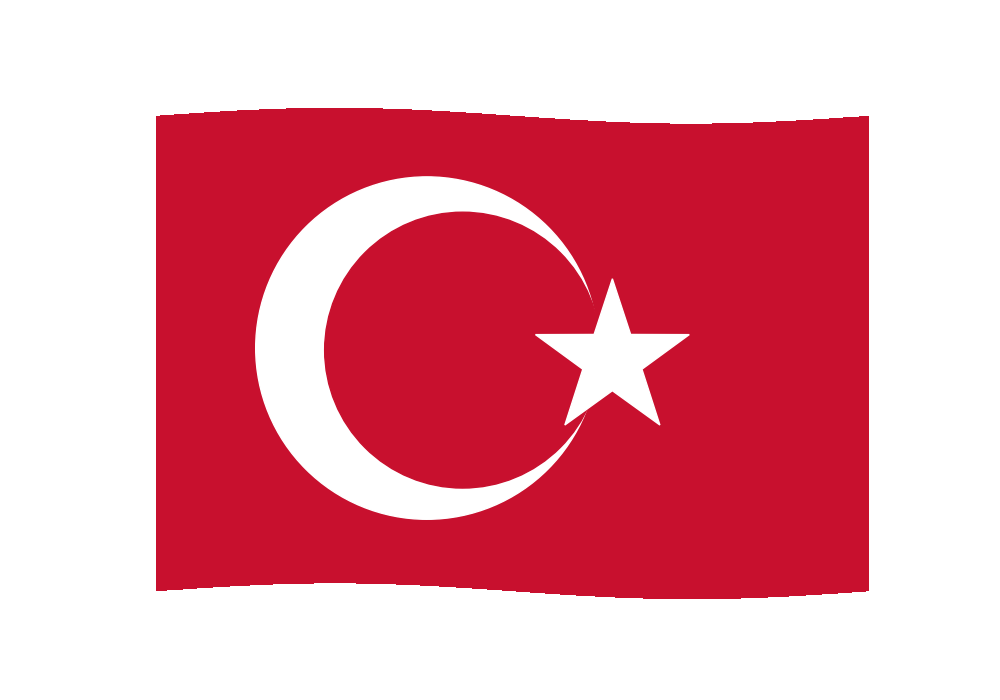

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Polygon
from matplotlib.animation import FuncAnimation
from IPython.display import Image, HTML


W, H = 4.5, 3


TURK_RED = "#C8102E"

A = 0.05
k = 2 * np.pi / W
speed = 0.06

def wave(x, t):
    return A * np.sin(k * x - t)

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, W)
ax.set_ylim(-0.2, H + 0.2)
ax.set_aspect("equal")
ax.axis("off")

x_vals = np.linspace(0, W, 500)
dx = W / 500
strips = []

for x in x_vals:
    r = Rectangle((x, 0), dx, H, color=TURK_RED, linewidth=0)
    ax.add_patch(r)
    strips.append(r)

outer_center_x = W * 0.38
inner_center_x = W * 0.43

outer_radius = H * 0.36
inner_radius = H * 0.29

outer = Circle((outer_center_x, H/2), outer_radius, color="white")
inner = Circle((inner_center_x, H/2), inner_radius, color=TURK_RED)

ax.add_patch(outer)
ax.add_patch(inner)

def star_points(cx, cy, R):
    angles = np.linspace(0, 2*np.pi, 11)
    pts = []
    for i, a in enumerate(angles[:-1]):
        r = R if i % 2 == 0 else R / 2.6
        pts.append((cx + r*np.sin(a), cy + r*np.cos(a)))
    return pts

star_x = W * 0.64
star_R = H * 0.17
star = Polygon(star_points(star_x, H/2, star_R), color="white")
ax.add_patch(star)

def update(frame):
    t = frame * speed

    for i, r in enumerate(strips):
        r.set_y(wave(x_vals[i], t))

    outer.center = (outer_center_x, H/2 + wave(outer_center_x, t))
    inner.center = (inner_center_x, H/2 + wave(inner_center_x, t))

    star.set_xy(
        star_points(
            star_x,
            H/2 + wave(star_x, t),
            star_R
        )
    )

    return strips + [outer, inner, star]

ani = FuncAnimation(fig, update, frames=140, interval=40)

gif_name = "turk_bayragi_dalgalanan.gif"
ani.save(gif_name, writer="pillow", fps=25)
plt.close()

display(Image(filename=gif_name))
files.download("turk_bayragi_dalgalanan.gif")
